In [1]:
import torch
print(f'PyTorch Version: {torch.__version__}')
print(f'CUDA Available: {torch.cuda.is_available()}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
torch.manual_seed(10000)

PyTorch Version: 2.9.1+cu128
CUDA Available: True
GPU: NVIDIA GeForce RTX 5080


检查路径

In [2]:
import os
print(os.listdir('AngularPS/processed_tensors/2512'))

['valid_data.pt', 'label_stats.pt', 'train_data.pt', 'test_data.pt']


导入其余包

In [3]:
import torch.nn as nn
import torch.optim as optim
from torchmetrics import MeanAbsoluteError
from torch.utils.data import TensorDataset, DataLoader

导入数据

In [4]:
def load_data():
    # 加载训练数据
    train_data = torch.load('AngularPS/processed_tensors/2512/train_data.pt')
    train_dataset = TensorDataset(train_data['images'], train_data['labels'])
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    valid_data = torch.load('AngularPS/processed_tensors/2512/valid_data.pt')
    valid_dataset = TensorDataset(valid_data['images'], valid_data['labels'])
    valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

    test_data = torch.load('AngularPS/processed_tensors/2512/test_data.pt')
    test_dataset = TensorDataset(test_data['images'], test_data['labels'])
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

    # 验证样本数量
    expected_sizes = {'train': 7200, 'valid': 900, 'test': 900}
    for dataset_type, dataset, data in [
        ('train', train_dataset, train_data),
        ('valid', valid_dataset, valid_data),
        ('test', test_dataset, test_data)
    ]:
        actual_size = len(dataset)
        expected_size = expected_sizes[dataset_type]
        if actual_size != expected_size:
            print(f"警告：{dataset_type} 数据集样本数量 ({actual_size}) 与预期 ({expected_size}) 不符！")

    print(train_data['images'].shape)  # 预期：(7200, 1, 20, 39)
    print(train_data['labels'].shape)  # 预期：(7200,)
    print(f"训练集: {len(train_dataset)} 样本, 数据形状 {train_dataset[0][0].shape}")
    print(f"验证集: {len(valid_dataset)} 样本, 数据形状 {valid_dataset[0][0].shape}")
    print(f"测试集: {len(test_dataset)} 样本, 数据形状 {test_dataset[0][0].shape}")
    return train_loader, valid_loader, test_loader

if __name__ == "__main__":
    train_loader, valid_loader, test_loader = load_data()

torch.Size([7200, 1, 8, 24])
torch.Size([7200, 2])
训练集: 7200 样本, 数据形状 torch.Size([1, 8, 24])
验证集: 900 样本, 数据形状 torch.Size([1, 8, 24])
测试集: 900 样本, 数据形状 torch.Size([1, 8, 24])


定义CNN模型

In [9]:
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # 输入形状: (batch_size, 1, 8, 24)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)  # 输出: (32, 8, 24)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2)                            # 输出: (32, 4, 12)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 输出: (64, 4, 12)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2)                            # 输出: (64, 2, 6)
        
        self.flatten = nn.Flatten()
        # 全连接层输入维度：64 * 2 * 6 = 768
        self.fc1 = nn.Linear(768, 256)
        self.relu3 = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(256, 2)  # 输出两个回归值 (klw, mcool)

    def forward(self, x):
        x = self.pool1(self.relu1(self.bn1(self.conv1(x))))
        x = self.pool2(self.relu2(self.bn2(self.conv2(x))))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

定义训练函数

In [6]:
def r2_score(y_true, y_pred):
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

from torchmetrics import R2Score

def train_model(model, train_loader, valid_loader, epochs=100, patience=30, w_klw=1.0, w_mcool=1):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    criterion = nn.MSELoss()
    mae = MeanAbsoluteError().to(device)  # MAE指标
    optimizer = optim.Adam(model.parameters(), lr=0.0003, weight_decay=1e-3)  # 增加weight_decay

    best_valid_loss = float('inf')
    early_stop_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss, train_mae_klw, train_mae_mcool = 0.0, 0.0, 0.0
        valid_r2_klw, valid_r2_mcool = 0.0, 0.0
        train_samples = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)  # x: (batch_size, 1, 20, 40), y: (batch_size, 2)
            optimizer.zero_grad()
            output = model(x)  # output: (batch_size, 2)
            
            # 计算加权损失
            loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw  # klw的损失
            loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool  # mcool的损失
            loss = loss_klw + loss_mcool
            
            loss.backward()
            optimizer.step()
            
            # 累积损失和MAE
            train_loss += loss.item() * x.size(0)
            train_mae_klw += mae(output[:, 0], y[:, 0]).item() * x.size(0)
            train_mae_mcool += mae(output[:, 1], y[:, 1]).item() * x.size(0)

            train_samples += x.size(0)
        
        train_loss /= train_samples
        train_mae_klw /= train_samples
        train_mae_mcool /= train_samples

        # 验证阶段
        model.eval()
        valid_loss, valid_mae_klw, valid_mae_mcool = 0.0, 0.0, 0.0
        valid_samples = 0
        predictions = []
        trues = []

        with torch.no_grad():
            for x, y in valid_loader:
                x, y = x.to(device), y.to(device)
                output = model(x)  # output: (batch_size, 2)
                
                # 计算加权验证损失
                loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw
                loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool
                loss = loss_klw + loss_mcool
                
                valid_loss += loss.item() * x.size(0)
                valid_mae_klw += mae(output[:, 0], y[:, 0]).item() * x.size(0)
                valid_mae_mcool += mae(output[:, 1], y[:, 1]).item() * x.size(0)
                valid_samples += x.size(0)
                predictions.append(model(x.to(device)).cpu())
                trues.append(y.cpu())
        
        valid_loss /= valid_samples
        valid_mae_klw /= valid_samples
        valid_mae_mcool /= valid_samples
        all_pred = torch.cat(predictions, dim=0)
        all_true = torch.cat(trues, dim=0)
        valid_r2_klw = r2_score(all_true[:, 0], all_pred[:, 0])
        valid_r2_mcool = r2_score(all_true[:, 1], all_pred[:, 1])

        print(f'Epoch {epoch+1}/{epochs}, '
              f'Train Loss: {train_loss:.4f}, Train MAE klw: {train_mae_klw:.4f}, Train MAE mcool: {train_mae_mcool:.4f}, '
              f'Valid Loss: {valid_loss:.4f}, Valid MAE klw: {valid_mae_klw:.4f}, Valid MAE mcool: {valid_mae_mcool:.4f}, '
              f'Valid R2 klw: {valid_r2_klw:.4f}, Valid R2 mcool: {valid_r2_mcool:.4f}')

        valid_r2_total = valid_r2_klw + valid_r2_mcool
        if 'best_valid_r2' not in locals():
            best_valid_r2 = -float('inf')
        if valid_r2_total > best_valid_r2:
            best_valid_r2 = valid_r2_total
            torch.save(model.state_dict(), 'best_model_smallpic.pt')
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping at epoch {epoch+1} (R2-based)")
                break

    # 加载最佳模型
    model.load_state_dict(torch.load('best_model_smallpic.pt'))
    return model

定义测试函数

In [7]:
import numpy as np
np.random.seed(100000)

def test_model(model, test_loader, w_klw=1.0, w_mcool=1):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()
    criterion = nn.MSELoss()  # 均方误差损失，适用于多输出回归
    mae = MeanAbsoluteError().to(device)  # MAE指标
    test_loss, test_mae_klw, test_mae_mcool = 0.0, 0.0, 0.0
    test_samples = 0
    predictions, trues = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)  # x: (batch_size, 1, 20, 40), y: (batch_size, 2)
            output = model(x)  # output: (batch_size, 2)
            
            # 计算加权损失
            loss_klw = criterion(output[:, 0], y[:, 0]) * w_klw  # klw的损失
            loss_mcool = criterion(output[:, 1], y[:, 1]) * w_mcool  # mcool的损失
            loss = loss_klw + loss_mcool
            
            # 累积损失和MAE
            test_loss += loss.item() * x.size(0)
            test_mae_klw += mae(output[:, 0], y[:, 0]).item() * x.size(0)
            test_mae_mcool += mae(output[:, 1], y[:, 1]).item() * x.size(0)
            test_samples += x.size(0)
            
            # 存储预测和真实值
            predictions.append(model(x.to(device)).cpu())  # (batch_size, 2)
            trues.append(y.cpu())  # (batch_size, 2)
        all_pred = torch.cat(predictions, dim=0)
        all_true = torch.cat(trues, dim=0)
        test_r2_klw = r2_score(all_true[:, 0], all_pred[:, 0])
        test_r2_mcool = r2_score(all_true[:, 1], all_pred[:, 1])

    test_loss /= test_samples
    test_mae_klw /= test_samples
    test_mae_mcool /= test_samples
    predictions = np.concatenate(predictions, axis=0)  # 形状：(N, 2)
    trues = np.concatenate(trues, axis=0)  # 形状：(N, 2)

    print(f'Test Loss: {test_loss:.4f}, Test MAE klw: {test_mae_klw:.4f}, Test MAE mcool: {test_mae_mcool:.4f}, Test R2 klw: {test_r2_klw:.4f}, Test R2 mcool: {test_r2_mcool:.4f}')
    return test_loss, test_mae_klw, test_mae_mcool, predictions, trues

主程序：加载数据、训练和测试

In [10]:
# 加载数据
train_loader, valid_loader, test_loader = load_data()

# 初始化模型
model = CNN()

# 训练（使用归一化标签，权重设为1.0）
model = train_model(model, train_loader, valid_loader, epochs=100, patience=50, w_klw=1.0, w_mcool=1.0)

# 加载最佳模型
model.load_state_dict(torch.load('best_model_smallpic.pt'))

# 测试
test_loss, test_mae_klw, test_mae_mcool, predictions, trues = test_model(model, test_loader, w_klw=1.0, w_mcool=1.0)

# 反归一化
label_stats = torch.load('AngularPS/processed_tensors/2512/label_stats.pt')
mean, std = label_stats['mean'], label_stats['std']
predictions = predictions * std.numpy() + mean.numpy()
trues = trues * std.numpy() + mean.numpy()

# 打印结果
print("部分测试集预测值与真实值（klw, mcool）：")
for i in range(min(5, len(predictions))):
    print(f"样本 {i+1}: 预测值=[{predictions[i, 0]:.4f}, {predictions[i, 1]:.4e}], "
          f"真实值=[{trues[i, 0]:.4f}, {trues[i, 1]:.4e}]")

torch.Size([7200, 1, 8, 24])
torch.Size([7200, 2])
训练集: 7200 样本, 数据形状 torch.Size([1, 8, 24])
验证集: 900 样本, 数据形状 torch.Size([1, 8, 24])
测试集: 900 样本, 数据形状 torch.Size([1, 8, 24])
Epoch 1/100, Train Loss: 1.2904, Train MAE klw: 0.6165, Train MAE mcool: 0.7015, Valid Loss: 1.1259, Valid MAE klw: 0.5471, Valid MAE mcool: 0.6784, Valid R2 klw: 0.4935, Valid R2 mcool: 0.3922
Epoch 2/100, Train Loss: 1.1973, Train MAE klw: 0.5908, Train MAE mcool: 0.6755, Valid Loss: 1.0664, Valid MAE klw: 0.5502, Valid MAE mcool: 0.6439, Valid R2 klw: 0.4965, Valid R2 mcool: 0.4427
Epoch 3/100, Train Loss: 1.1794, Train MAE klw: 0.5893, Train MAE mcool: 0.6655, Valid Loss: 1.1019, Valid MAE klw: 0.5948, Valid MAE mcool: 0.6363, Valid R2 klw: 0.4397, Valid R2 mcool: 0.4552
Epoch 4/100, Train Loss: 1.1629, Train MAE klw: 0.5850, Train MAE mcool: 0.6600, Valid Loss: 1.0571, Valid MAE klw: 0.5395, Valid MAE mcool: 0.6488, Valid R2 klw: 0.4964, Valid R2 mcool: 0.4511
Epoch 5/100, Train Loss: 1.1435, Train MAE klw: 0

测试集参数估计可视化

torch.Size([7200, 1, 8, 24])
torch.Size([7200, 2])
训练集: 7200 样本, 数据形状 torch.Size([1, 8, 24])
验证集: 900 样本, 数据形状 torch.Size([1, 8, 24])
测试集: 900 样本, 数据形状 torch.Size([1, 8, 24])
Test Loss: 1.0175, Test MAE klw: 0.5559, Test MAE mcool: 0.6110, Test R2 klw: 0.5083, Test R2 mcool: 0.1831


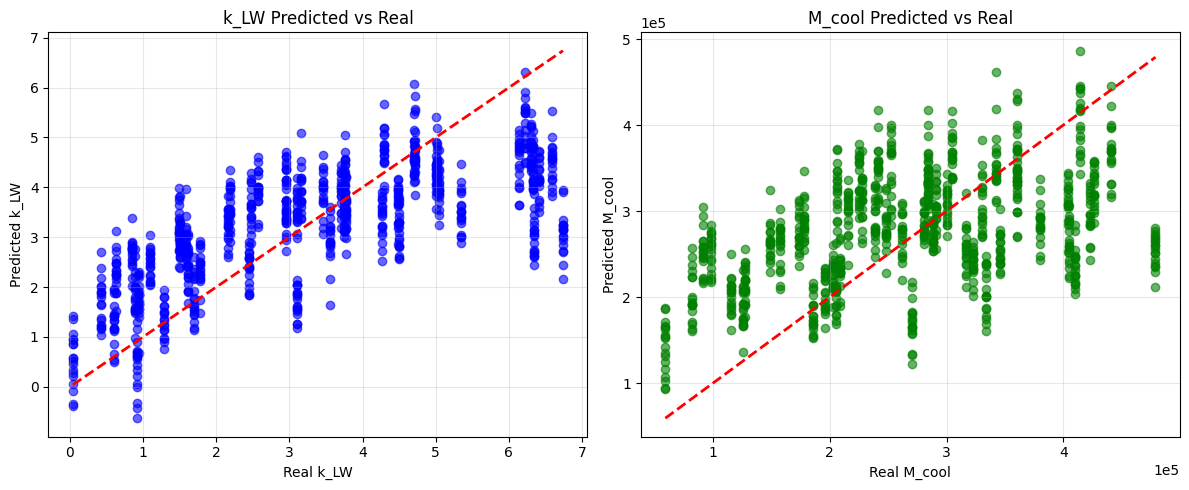

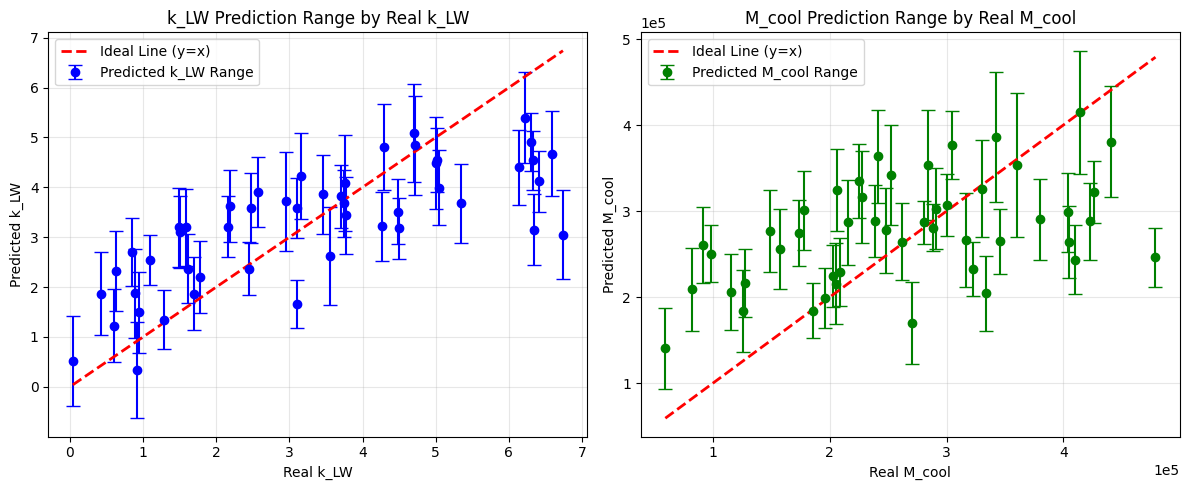

k_LW 分组统计（真实 k_LW -> 预测 k_LW 范围）：
k_LW_real=0.04: k_LW_pred=[-0.3773, 1.4138] (样本数: 18)
k_LW_real=0.43: k_LW_pred=[1.0338, 2.6968] (样本数: 18)
k_LW_real=0.60: k_LW_pred=[0.4936, 1.9606] (样本数: 18)
k_LW_real=0.63: k_LW_pred=[1.5191, 3.1170] (样本数: 18)
k_LW_real=0.85: k_LW_pred=[2.0275, 3.3795] (样本数: 18)
k_LW_real=0.89: k_LW_pred=[0.9732, 2.7721] (样本数: 18)
k_LW_real=0.92: k_LW_pred=[-0.6295, 1.2916] (样本数: 18)
k_LW_real=0.94: k_LW_pred=[0.6808, 2.3102] (样本数: 18)
k_LW_real=1.10: k_LW_pred=[2.0327, 3.0465] (样本数: 18)
k_LW_real=1.28: k_LW_pred=[0.7503, 1.9369] (样本数: 18)
k_LW_real=1.49: k_LW_pred=[2.4032, 3.9950] (样本数: 18)
k_LW_real=1.50: k_LW_pred=[2.3750, 3.8203] (样本数: 18)
k_LW_real=1.59: k_LW_pred=[2.4229, 3.9682] (样本数: 18)
k_LW_real=1.62: k_LW_pred=[1.6739, 3.0704] (样本数: 18)
k_LW_real=1.70: k_LW_pred=[1.1433, 2.5990] (样本数: 18)
k_LW_real=1.78: k_LW_pred=[1.4838, 2.9339] (样本数: 18)
k_LW_real=2.16: k_LW_pred=[2.6018, 3.8263] (样本数: 18)
k_LW_real=2.19: k_LW_pred=[2.9063, 4.3471] (样本数: 18)
k_LW_real=

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt


# 加载数据（仅测试集）
_, _, test_loader = load_data()

# 初始化模型并加载最佳权重
model = CNN()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
model.load_state_dict(torch.load('best_model_smallpic.pt'))
model.eval()

# 测试模型，获取预测和真实值
test_loss, test_mae_klw, test_mae_mcool, predictions, trues = test_model(model, test_loader, w_klw=1.0, w_mcool=1.0)

# 反归一化
label_stats = torch.load('AngularPS/processed_tensors/2512/label_stats.pt')
mean = label_stats['mean']  # [klw_mean, mcool_mean]
std = label_stats['std']    # [klw_std, mcool_std]
predictions = predictions * std.numpy() + mean.numpy()  # 形状: (900, 2)
trues = trues * std.numpy() + mean.numpy()             # 形状: (900, 2)

# 1. 可视化预测结果：散点图比较预测值 vs 真实值
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# k_LW的散点图
axes[0].scatter(trues[:, 0], predictions[:, 0], alpha=0.6, color='blue')
axes[0].plot([trues[:, 0].min(), trues[:, 0].max()], [trues[:, 0].min(), trues[:, 0].max()], 'r--', lw=2)
axes[0].set_xlabel('Real k_LW')
axes[0].set_ylabel('Predicted k_LW')
axes[0].set_title('k_LW Predicted vs Real')
axes[0].grid(True, alpha=0.3)

# M_cool的散点图（使用科学计数法）
axes[1].scatter(trues[:, 1], predictions[:, 1], alpha=0.6, color='green')
axes[1].plot([trues[:, 1].min(), trues[:, 1].max()], [trues[:, 1].min(), trues[:, 1].max()], 'r--', lw=2)
axes[1].set_xlabel('Real M_cool')
axes[1].set_ylabel('Predicted M_cool')
axes[1].set_title('M_cool Predicted vs Real')
axes[1].ticklabel_format(style='sci', axis='both', scilimits=(0,0))  # 科学计数法
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_scatter_smallpic.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. 误差棒图：按真实值分组，计算对应预测值的最大和最小值范围
# 第一张：按真实 k_LW 分组，计算预测 k_LW 的最大和最小值
unique_klw_real = np.unique(trues[:, 0])
unique_klw_real.sort()

max_klw_pred = []
min_klw_pred = []
sample_counts_klw = []

for klw_real in unique_klw_real:
    mask = np.isclose(trues[:, 0], klw_real, atol=1e-4)
    group_klw_preds = predictions[mask, 0]
    
    if len(group_klw_preds) > 0:
        max_klw_pred.append(np.max(group_klw_preds))
        min_klw_pred.append(np.min(group_klw_preds))
        sample_counts_klw.append(np.sum(mask))
    else:
        max_klw_pred.append(np.nan)
        min_klw_pred.append(np.nan)
        sample_counts_klw.append(0)

max_klw_pred = np.array(max_klw_pred)
min_klw_pred = np.array(min_klw_pred)
sample_counts_klw = np.array(sample_counts_klw)

# 第二张：按真实 M_cool 分组，计算预测 M_cool 的最大和最小值
unique_mcool_real = np.unique(trues[:, 1])
unique_mcool_real.sort()

max_mcool_pred = []
min_mcool_pred = []
sample_counts_mcool = []

for mcool_real in unique_mcool_real:
    mask = np.isclose(trues[:, 1], mcool_real, atol=1e-4)
    group_mcool_preds = predictions[mask, 1]
    
    if len(group_mcool_preds) > 0:
        max_mcool_pred.append(np.max(group_mcool_preds))
        min_mcool_pred.append(np.min(group_mcool_preds))
        sample_counts_mcool.append(np.sum(mask))
    else:
        max_mcool_pred.append(np.nan)
        min_mcool_pred.append(np.nan)
        sample_counts_mcool.append(0)

max_mcool_pred = np.array(max_mcool_pred)
min_mcool_pred = np.array(min_mcool_pred)
sample_counts_mcool = np.array(sample_counts_mcool)

# 绘制误差棒图
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 第一张：k_LW 误差棒图（横轴：真实 k_LW，纵轴：预测 k_LW 范围）
axes[0].errorbar(unique_klw_real, (max_klw_pred + min_klw_pred) / 2, yerr=[(max_klw_pred - min_klw_pred) / 2], 
                 fmt='o', capsize=5, color='blue', label='Predicted k_LW Range')
axes[0].plot(unique_klw_real, unique_klw_real, 'r--', lw=2, label='Ideal Line (y=x)')
axes[0].set_xlabel('Real k_LW')
axes[0].set_ylabel('Predicted k_LW')
axes[0].set_title('k_LW Prediction Range by Real k_LW')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 第二张：M_cool 误差棒图（横轴：真实 M_cool，纵轴：预测 M_cool 范围）
axes[1].errorbar(unique_mcool_real, (max_mcool_pred + min_mcool_pred) / 2, yerr=[(max_mcool_pred - min_mcool_pred) / 2], 
                 fmt='o', capsize=5, color='green', label='Predicted M_cool Range')
axes[1].plot(unique_mcool_real, unique_mcool_real, 'r--', lw=2, label='Ideal Line (y=x)')
axes[1].set_xlabel('Real M_cool')
axes[1].set_ylabel('Predicted M_cool')
axes[1].set_title('M_cool Prediction Range by Real M_cool')
axes[1].ticklabel_format(style='sci', axis='both', scilimits=(0,0))  # 科学计数法
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('error_bar_plot_smallpic.png', dpi=300, bbox_inches='tight')
plt.show()

# 打印分组统计
print("k_LW 分组统计（真实 k_LW -> 预测 k_LW 范围）：")
for i, klw_real in enumerate(unique_klw_real):
    if not np.isnan(max_klw_pred[i]):
        print(f"k_LW_real={klw_real:.2f}: k_LW_pred=[{min_klw_pred[i]:.4f}, {max_klw_pred[i]:.4f}] (样本数: {sample_counts_klw[i]})")

print("\nM_cool 分组统计（真实 M_cool -> 预测 M_cool 范围）：")
for i, mcool_real in enumerate(unique_mcool_real):
    if not np.isnan(max_mcool_pred[i]):
        print(f"M_cool_real={mcool_real:.4e}: M_cool_pred=[{min_mcool_pred[i]:.4e}, {max_mcool_pred[i]:.4e}] (样本数: {sample_counts_mcool[i]})")

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- k_LW 分组统计 ---
klw_data = {
    "k_LW_real": np.round(unique_klw_real, 4),
    "k_LW_pred_min": min_klw_pred,
    "k_LW_pred_max": max_klw_pred,
    "sample_count": sample_counts_klw
}
df_klw = pd.DataFrame(klw_data)

# 去除无效行（如果某些分组没有数据）
df_klw = df_klw.dropna()

# 保存
df_klw.to_csv("k_LW_group_stats_smallpic.csv", index=False)
print("已保存：k_LW_group_stats_smallpic.csv")

# --- M_cool 分组统计 ---
mcool_data = {
    "M_cool_real": unique_mcool_real,
    "M_cool_pred_min": min_mcool_pred,
    "M_cool_pred_max": max_mcool_pred,
    "sample_count": sample_counts_mcool
}
df_mcool = pd.DataFrame(mcool_data)
df_mcool = df_mcool.dropna()

df_mcool.to_csv("M_cool_group_stats_smallpic.csv", index=False)
print("已保存：M_cool_group_stats_smallpic.csv")


The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.
已保存：k_LW_group_stats_10000.csv
已保存：M_cool_group_stats_10000.csv


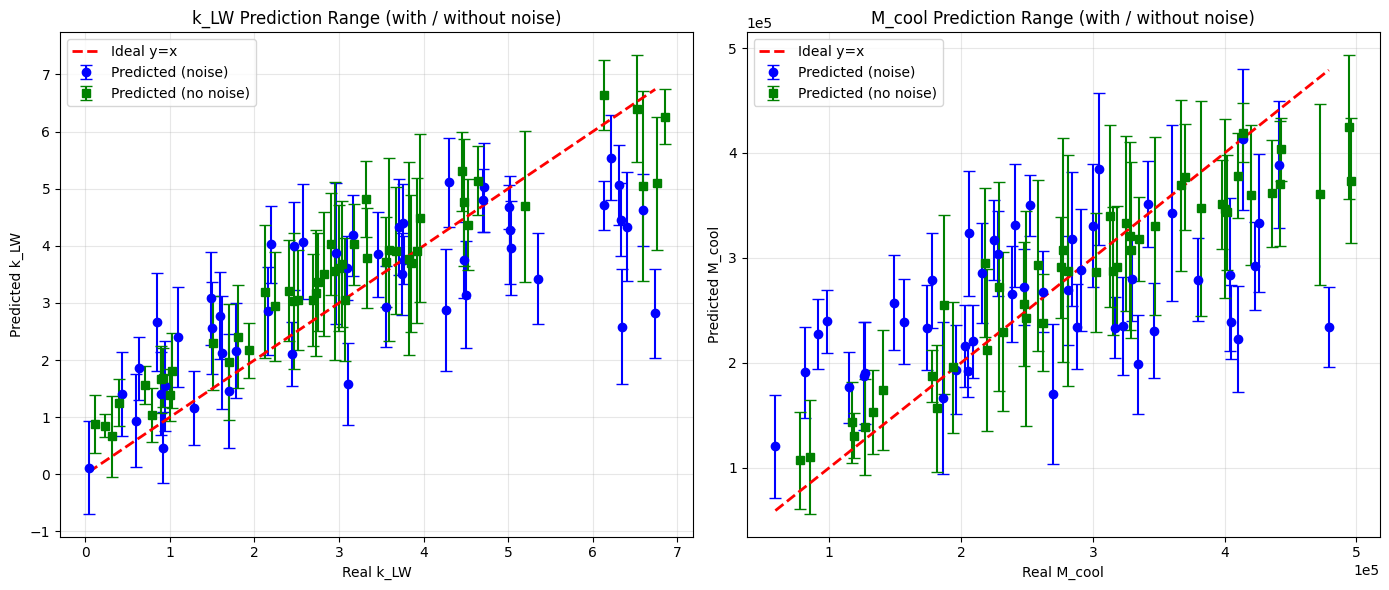

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 读取四组数据
df_k = pd.read_csv("k_LW_group_stats_smallpic.csv")                # 含噪音
df_k_nonoise = pd.read_csv("k_LW_group_stats_nonoise.csv") # 无噪音

df_m = pd.read_csv("M_cool_group_stats_smallpic.csv")                # 含噪音
df_m_nonoise = pd.read_csv("M_cool_group_stats_nonoise.csv") # 无噪音

# 创建画布
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ========== 第一张：k_LW ==========
ax = axes[0]

# 含噪音
mid_k = (df_k["k_LW_pred_min"] + df_k["k_LW_pred_max"]) / 2
err_k = (df_k["k_LW_pred_max"] - df_k["k_LW_pred_min"]) / 2

ax.errorbar(df_k["k_LW_real"], mid_k, yerr=err_k,
            fmt='o', capsize=4, label="Predicted (noise)", color="blue")

# 无噪音
mid_k_n = (df_k_nonoise["k_LW_pred_min"] + df_k_nonoise["k_LW_pred_max"]) / 2
err_k_n = (df_k_nonoise["k_LW_pred_max"] - df_k_nonoise["k_LW_pred_min"]) / 2

ax.errorbar(df_k_nonoise["k_LW_real"], mid_k_n, yerr=err_k_n,
            fmt='s', capsize=4, label="Predicted (no noise)", color="green")

# 理想线 y=x
ax.plot(df_k["k_LW_real"], df_k["k_LW_real"], 'r--', lw=2, label='Ideal y=x')

ax.set_xlabel("Real k_LW")
ax.set_ylabel("Predicted k_LW")
ax.set_title("k_LW Prediction Range (with / without noise)")
ax.grid(True, alpha=0.3)
ax.legend()


# ========== 第二张：M_cool ==========
ax = axes[1]

# 含噪音
mid_m = (df_m["M_cool_pred_min"] + df_m["M_cool_pred_max"]) / 2
err_m = (df_m["M_cool_pred_max"] - df_m["M_cool_pred_min"]) / 2

ax.errorbar(df_m["M_cool_real"], mid_m, yerr=err_m,
            fmt='o', capsize=4, label="Predicted (noise)", color="blue")

# 无噪音
mid_m_n = (df_m_nonoise["M_cool_pred_min"] + df_m_nonoise["M_cool_pred_max"]) / 2
err_m_n = (df_m_nonoise["M_cool_pred_max"] - df_m_nonoise["M_cool_pred_min"]) / 2

ax.errorbar(df_m_nonoise["M_cool_real"], mid_m_n, yerr=err_m_n,
            fmt='s', capsize=4, label="Predicted (no noise)", color="green")

# 理想线 y=x
ax.plot(df_m["M_cool_real"], df_m["M_cool_real"], 'r--', lw=2, label='Ideal y=x')

ax.set_xlabel("Real M_cool")
ax.set_ylabel("Predicted M_cool")
ax.set_title("M_cool Prediction Range (with / without noise)")
ax.ticklabel_format(style='sci', axis='both', scilimits=(0,0))
ax.grid(True, alpha=0.3)
ax.legend()


plt.tight_layout()
plt.savefig("error_bar_plot_combined_smallpic.png", dpi=300, bbox_inches='tight')
plt.show()
